# 墨尔本房价数据分析报告

**数据集：** Melbourne Housing Data  
**分析目标：** 探索影响房价的关键因素及价格趋势  
**工具：** Python / Pandas / Matplotlib / Seaborn


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style='whitegrid', font_scale=1.2)

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [32]:
df = pd.read_csv('melbourne-housing-data/melb_data.csv')

## 1.数据概览

In [33]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


## 2.数据基本信息

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

## 3.检查重复值

In [35]:
df.duplicated().sum()

np.int64(0)

## 4.检查空值

In [36]:
df.isnull().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

## 5.数据统计描述

In [37]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


## 二、数据清洗

# 1. 异常值处理

In [38]:
# YearBuilt < 1850 视为无效数据
df.loc[df['YearBuilt'] < 1850, 'YearBuilt'] = np.nan

# Bedroom2 > Rooms 不合理，修正为 Rooms 的值
df.loc[df['Bedroom2'] > df['Rooms'], 'Bedroom2'] = df['Rooms']

# Car > 5 不合理，封顶为 5
df.loc[df['Car'] > 5, 'Car'] = 5

# Bathroom > Rooms+1 不合理，修正
df.loc[df['Bathroom'] > df['Rooms'] + 1, 'Bathroom'] = df['Rooms'] + 1

# 删除价格低于10万的异常记录
df = df[df['Price'] >= 100000]

print('异常值处理完成，当前数据量：', df.shape[0])

异常值处理完成，当前数据量： 13579


# 2. 极端值封顶

In [39]:
# Landsize 封顶
Q1_l = df['Landsize'].quantile(0.25)
Q3_l = df['Landsize'].quantile(0.75)
land_cap = Q3_l + 3.0 * (Q3_l - Q1_l)
df.loc[df['Landsize'] > land_cap, 'Landsize'] = land_cap

# BuildingArea 封顶
Q1_b = df['BuildingArea'].quantile(0.25)
Q3_b = df['BuildingArea'].quantile(0.75)
build_cap = Q3_b + 3.0 * (Q3_b - Q1_b)
df.loc[df['BuildingArea'] > build_cap, 'BuildingArea'] = build_cap

print(f'Landsize 封顶值: {land_cap:.1f}')
print(f'BuildingArea 封顶值: {build_cap:.1f}')


Landsize 封顶值: 2073.0
BuildingArea 封顶值: 417.0


#### 封顶前异常值分布（箱线图验证）

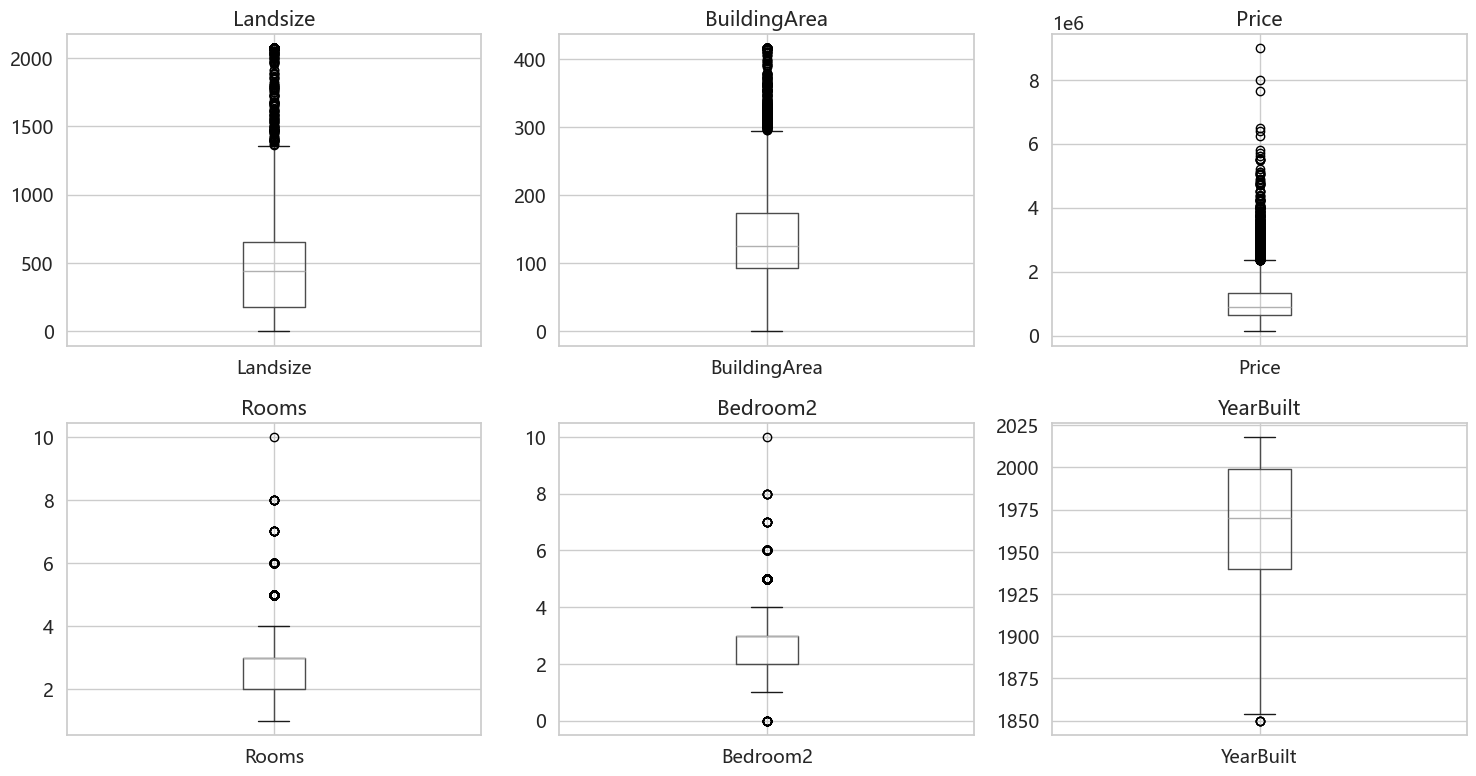

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, ['Landsize', 'BuildingArea', 'Price', 'Rooms', 'Bedroom2', 'YearBuilt']):
      df.boxplot(column=col, ax=ax)
      ax.set_title(col)
plt.tight_layout()
plt.show()

**箱线图分析：**
- Landsize 和 BuildingArea 上方仍有少量离群点，已通过 IQR 封顶处理极端值
- Price 存在高价异常值（800万以上），属于真实豪宅数据，保留
- Rooms 和 Bedroom2 最大值为10，合理范围内
- YearBuilt 最小值约1850，已将1850年以前的数据处理为空值

# 3. 无效值转为 NaN（面积为0没有意义）

In [41]:
df.loc[df['Landsize'] < 50, 'Landsize'] = np.nan
df.loc[df['BuildingArea'] < 30, 'BuildingArea'] = np.nan
df.loc[df['Landsize'] == 0, 'Landsize'] = np.nan
df.loc[df['BuildingArea'] == 0, 'BuildingArea'] = np.nan

print('转换后空值数量：')
print(df[['Landsize', 'BuildingArea']].isnull().sum())

转换后空值数量：
Landsize        1968
BuildingArea    6559
dtype: int64


# 4. 空值填补（按区域/房间数的中位数填补）

In [42]:
# Landsize：按 Suburb 填补，剩余用全局中位数
df['Landsize'] = df['Landsize'].fillna(
    df.groupby('Suburb')['Landsize'].transform('median'))
df['Landsize'] = df['Landsize'].fillna(df['Landsize'].median())

# BuildingArea：先按 Suburb+Rooms，再按 Suburb，再按 Rooms
df['BuildingArea'] = df['BuildingArea'].fillna(
    df.groupby(['Suburb', 'Rooms'])['BuildingArea'].transform('median'))
df['BuildingArea'] = df['BuildingArea'].fillna(
    df.groupby('Suburb')['BuildingArea'].transform('median'))
df['BuildingArea'] = df['BuildingArea'].fillna(
    df.groupby('Rooms')['BuildingArea'].transform('median'))

# YearBuilt：按 Suburb+Type，再按 Suburb，再按 CouncilArea
df['YearBuilt'] = df['YearBuilt'].fillna(
    df.groupby(['Suburb', 'Type'])['YearBuilt'].transform('median'))
df['YearBuilt'] = df['YearBuilt'].fillna(
    df.groupby('Suburb')['YearBuilt'].transform('median'))
df['YearBuilt'] = df['YearBuilt'].fillna(
    df.groupby('CouncilArea')['YearBuilt'].transform('median'))
df['YearBuilt'] = df['YearBuilt'].round(0).astype('Int64')

# Car：按 Suburb 填补
df['Car'] = df['Car'].fillna(
    df.groupby('Suburb')['Car'].transform('median')
).round().astype('Int64')

# CouncilArea：按 Postcode 众数填补
df['CouncilArea'] = df['CouncilArea'].fillna(
    df.groupby('Postcode')['CouncilArea'].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))

print('填补后空值数量：')
print(df.isnull().sum())

填补后空值数量：
Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        6
CouncilArea      3
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64


# 5. 数据类型转换

In [43]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Postcode'] = df['Postcode'].astype('Int64')
df['Bedroom2'] = df['Bedroom2'].astype('Int64')
df['Bathroom'] = df['Bathroom'].astype('Int64')
df['Propertycount'] = df['Propertycount'].astype('Int64')

print('类型转换完成')
print(df.dtypes)

类型转换完成
Suburb                      str
Address                     str
Rooms                     int64
Type                        str
Price                   float64
Method                      str
SellerG                     str
Date             datetime64[us]
Distance                float64
Postcode                  Int64
Bedroom2                  Int64
Bathroom                  Int64
Car                       Int64
Landsize                float64
BuildingArea            float64
YearBuilt                 Int64
CouncilArea                 str
Lattitude               float64
Longtitude              float64
Regionname                  str
Propertycount             Int64
dtype: object


# 清洗完成确认

In [44]:
print('清洗后数据量：', df.shape)
print('剩余空值：')
print(df.isnull().sum()[df.isnull().sum() > 0])

清洗后数据量： (13579, 21)
剩余空值：
YearBuilt      6
CouncilArea    3
dtype: int64


### 清洗结论

- 清洗后数据量：13579 条，21个字段
- 剩余空值：YearBuilt 6条，CouncilArea 3条，共9条
- 占总数据 0.07%，数量极少，不影响后续分析，保留处理

## 三、可视化分析

### 1.房价分布（直方图）

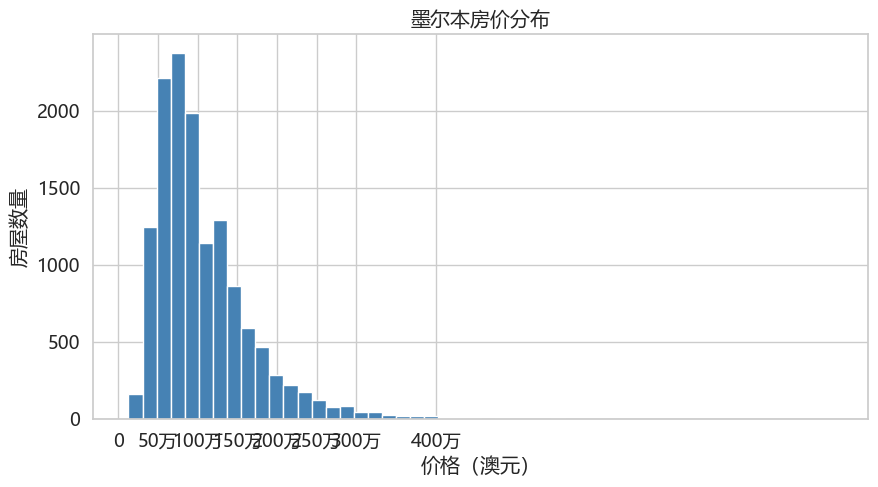

In [45]:
plt.figure(figsize=(10, 5))
plt.hist(df['Price'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.title('墨尔本房价分布')
plt.xlabel('价格（澳元）')
plt.ylabel('房屋数量')
plt.ticklabel_format(style='plain', axis='x')  
plt.xticks([0, 500000, 1000000, 1500000, 2000000, 2500000, 3000000,4000000],
             ['0', '50万', '100万', '150万', '200万', '250万', '300万','400万'])
plt.show()

**房价分布结论：**
- 房价呈明显右偏分布，主要集中在 60~120 万澳元区间
- 均值被少数高价豪宅拉高，后续分析统一使用中位数代表典型房价
- 300万以上的房源极少，属于高端市场

### 2.各区域房价对比（柱状图）

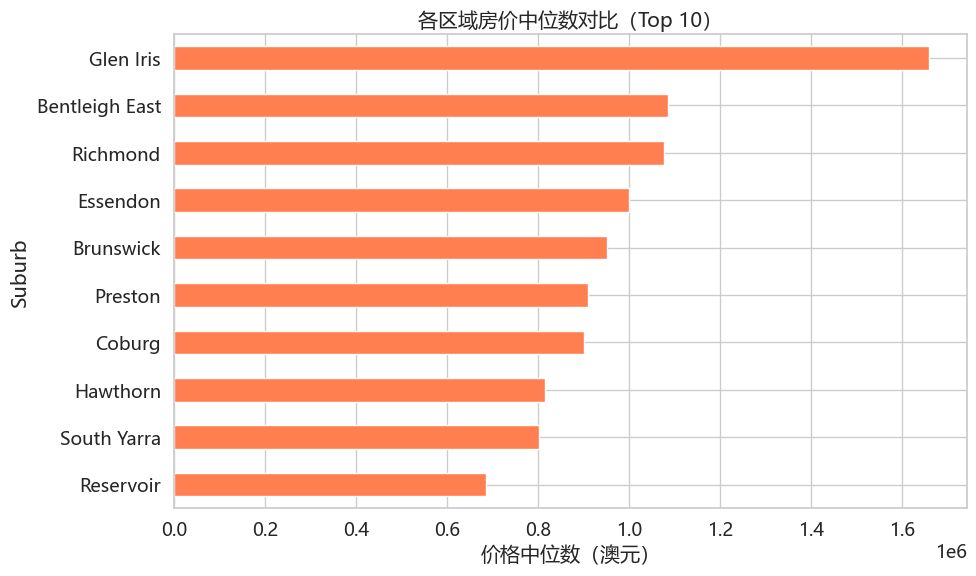

In [46]:
# 取房源最多的前10个区域
top_suburbs = df['Suburb'].value_counts().head(10).index
suburb_price = (df[df['Suburb'].isin(top_suburbs)]
                  .groupby('Suburb')['Price']
                  .median()
                  .sort_values(ascending=True))

plt.figure(figsize=(10, 6))
suburb_price.plot(kind='barh', color='coral', edgecolor='white')
plt.title('各区域房价中位数对比（Top 10）')
plt.xlabel('价格中位数（澳元）')
plt.tight_layout()
plt.show()

**结论：**
- Glen Iris 房价中位数最高（约165万），Reservoir 最低（约70万）
- 同为热门区域，最高与最低价差超过2倍
- 区域位置是影响房价的重要因素，购房者可根据预算优先筛选区域

### 3.特征与价格关系（散点图）

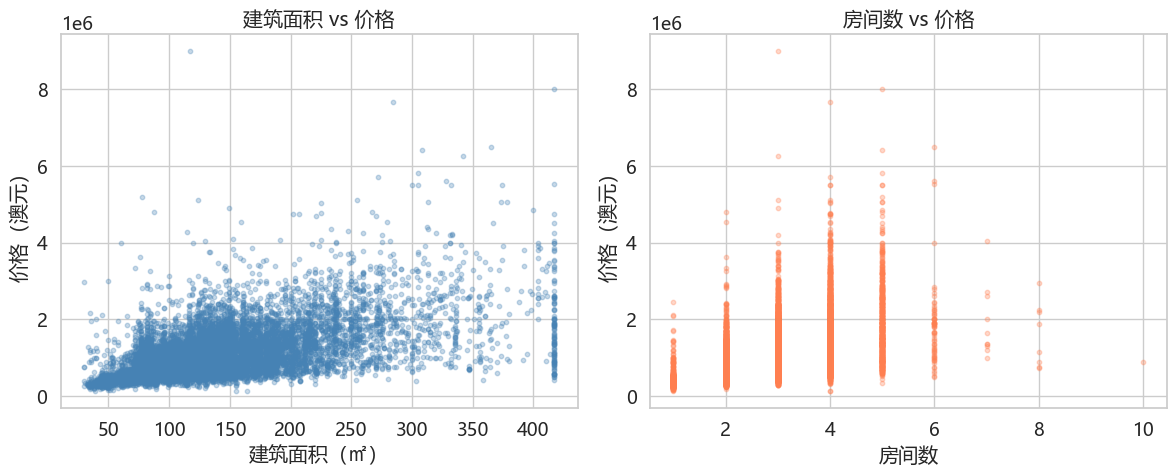

In [47]:
df_scatter = df[(df['BuildingArea'] > 0) & (df['BuildingArea'] < 500)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# 左图：建筑面积 vs 价格
axes[0].scatter(df_scatter['BuildingArea'], df_scatter['Price'],
                  alpha=0.3, color='steelblue', s=10)
axes[0].set_title('建筑面积 vs 价格')
axes[0].set_xlabel('建筑面积（㎡）')
axes[0].set_ylabel('价格（澳元）')

  # 右图：房间数 vs 价格
axes[1].scatter(df['Rooms'], df['Price'],
                  alpha=0.3, color='coral', s=10)
axes[1].set_title('房间数 vs 价格')
axes[1].set_xlabel('房间数')
axes[1].set_ylabel('价格（澳元）')

plt.tight_layout()
plt.show()

**结论：**
- 建筑面积与房价存在正相关，面积越大价格越高
- 房间数与房价有一定正相关，但同房间数下价格波动很大
- 单独用房间数或面积预测房价不可靠，需结合多个特征


### 4.区域房价分布（箱线图）

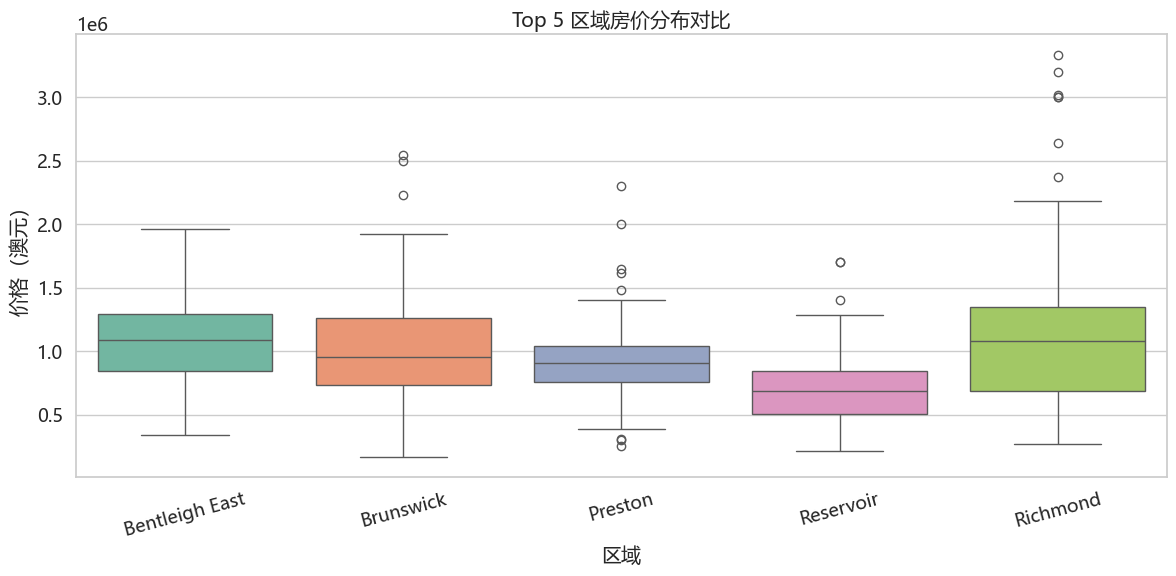

In [48]:
# 取前5个房源最多的区域
top5 = df['Suburb'].value_counts().head(5).index
df_top5 = df[df['Suburb'].isin(top5)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='Suburb', y='Price', data=df_top5,
              hue='Suburb', palette='Set2', legend=False)
plt.title('Top 5 区域房价分布对比')
plt.xlabel('区域')
plt.ylabel('价格（澳元）')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**结论：**
- Richmond 和 Bentleigh East 中位数最高，箱体较宽，房价差异大
- Reservoir 中位数最低，箱体较窄，价格相对稳定
- 每个区域都存在明显异常值，说明高端房产在各区域均有分布

### 5.特征相关性（热力图）

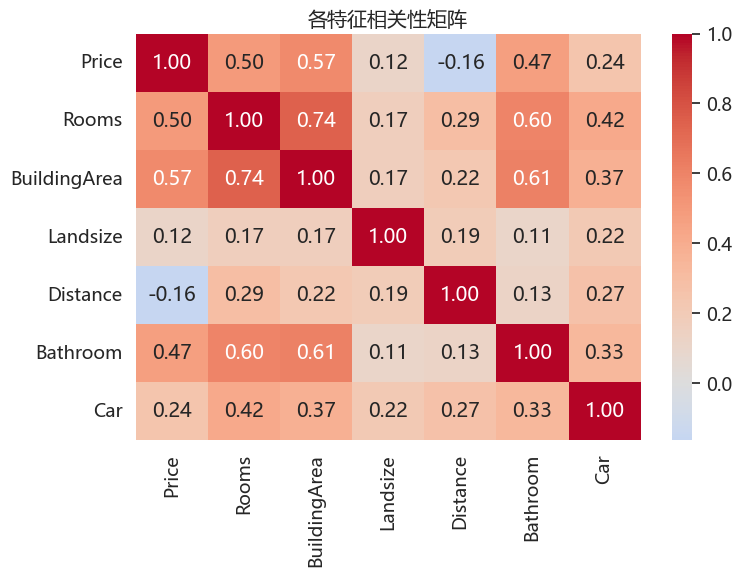

In [49]:
cols = ['Price', 'Rooms', 'BuildingArea', 'Landsize', 'Distance', 'Bathroom', 'Car']
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('各特征相关性矩阵')
plt.tight_layout()
plt.show()

**结论：**
- 房间数（0.50）和卫浴数（0.47）与房价相关性最强
- 距离市中心负相关（-0.16），离市中心越远房价越低
- 建筑面积相关性极弱（0.09），与数据集该字段缺失值较多有关

### 6.房价月度趋势（折线图）

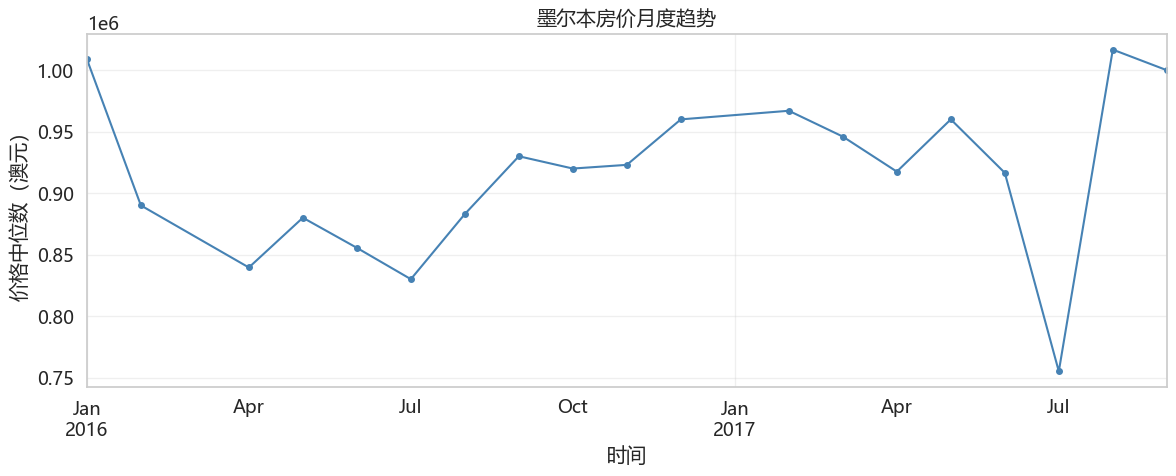

In [50]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['YearMonth'] = df['Date'].dt.to_period('M')

monthly_price = df.groupby('YearMonth')['Price'].median()

plt.figure(figsize=(12, 5))
monthly_price.plot(kind='line', marker='o', color='steelblue', markersize=4)
plt.title('墨尔本房价月度趋势')
plt.xlabel('时间')
plt.ylabel('价格中位数（澳元）')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**结论：**
- 2016~2017年墨尔本房价整体呈上涨趋势
- 每年年中（6~7月）出现季节性低谷，年初和年底价格相对较高
- 2017年7月出现异常低点，可能与当月样本量少有关，并非真实市场下跌


### 7.综合分析（子图）

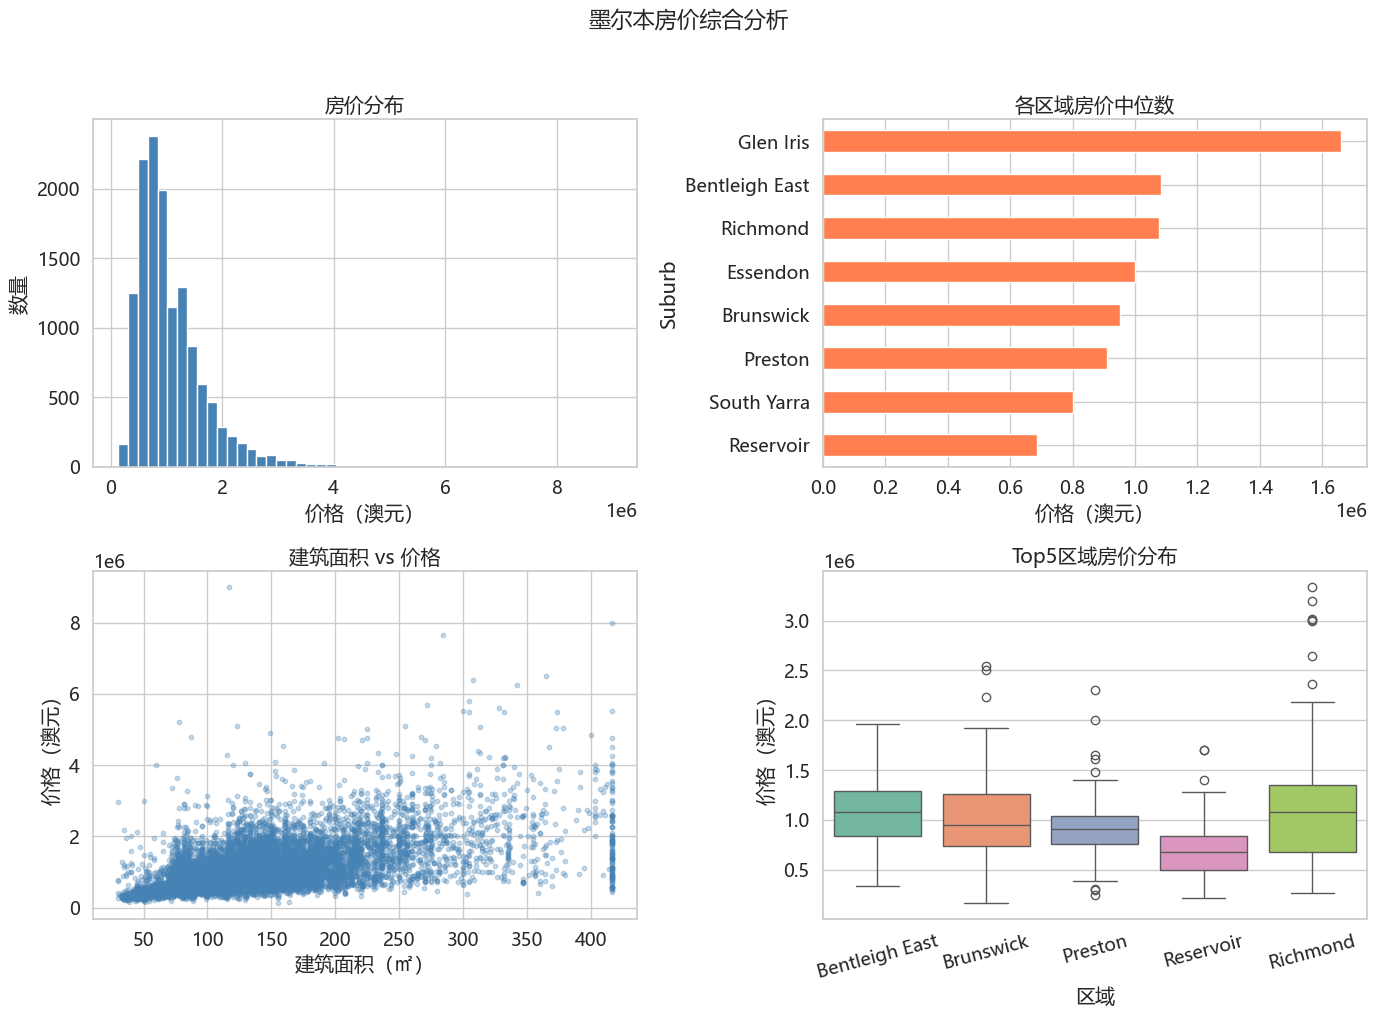

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('墨尔本房价综合分析', fontsize=16, y=1.02)

  # 左上：房价分布
axes[0, 0].hist(df['Price'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('房价分布')
axes[0, 0].set_xlabel('价格（澳元）')
axes[0, 0].set_ylabel('数量')

  # 右上：各区域房价
top_suburbs = df['Suburb'].value_counts().head(8).index
suburb_price = (df[df['Suburb'].isin(top_suburbs)]
                  .groupby('Suburb')['Price']
                  .median()
                  .sort_values())
suburb_price.plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('各区域房价中位数')
axes[0, 1].set_xlabel('价格（澳元）')

  # 左下：面积vs价格
axes[1, 0].scatter(df['BuildingArea'], df['Price'], alpha=0.3, color='steelblue', s=10)
axes[1, 0].set_title('建筑面积 vs 价格')
axes[1, 0].set_xlabel('建筑面积（㎡）')
axes[1, 0].set_ylabel('价格（澳元）')

  # 右下：箱线图
top5 = df['Suburb'].value_counts().head(5).index
df_top5 = df[df['Suburb'].isin(top5)]
sns.boxplot(x='Suburb', y='Price', data=df_top5, hue='Suburb', palette='Set2', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Top5区域房价分布')
axes[1, 1].set_xlabel('区域')
axes[1, 1].set_ylabel('价格（澳元）')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**综合结论：**
- 房价分布右偏，中位数约100万澳元，分析时统一使用中位数
- 区域是影响房价的关键因素，Glen Iris 与 Reservoir 价差超过2倍
- BuildingArea 异常值较多，与价格相关性低，建模时需单独处理
- Richmond、Bentleigh East 房价波动大；Reservoir 价格稳定适合预算有限的买家

### 8.美化图表

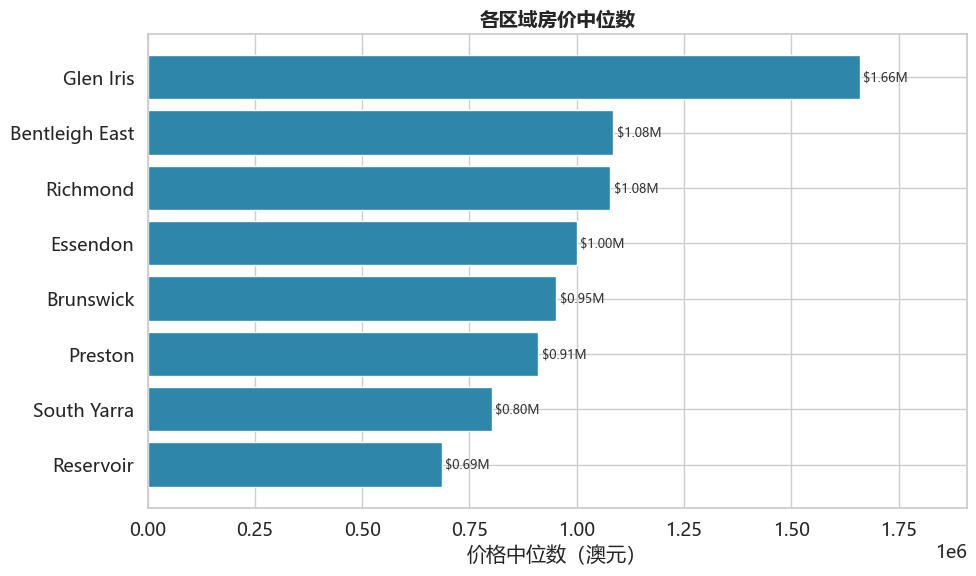

In [52]:
top_suburbs = df['Suburb'].value_counts().head(8).index
suburb_price = (df[df['Suburb'].isin(top_suburbs)]
                .groupby('Suburb')['Price']
                .median()
                .sort_values())

plt.figure(figsize=(10, 6))
bars = plt.barh(suburb_price.index, suburb_price.values, 
                color='#2E86AB', edgecolor='white')

# 在每个柱子末端加价格数字
for bar, val in zip(bars, suburb_price.values):
    plt.text(val + 8000, 
             bar.get_y() + bar.get_height()/2,
             f'${val/1e6:.2f}M',  # 显示成 $1.05M 格式
             va='center', fontsize=9, color='#333333')

plt.title('各区域房价中位数', fontsize=14, fontweight='bold')
plt.xlabel('价格中位数（澳元）')
plt.xlim(0, suburb_price.max() * 1.15)  # 右边留空间放标签
plt.tight_layout()
plt.show()


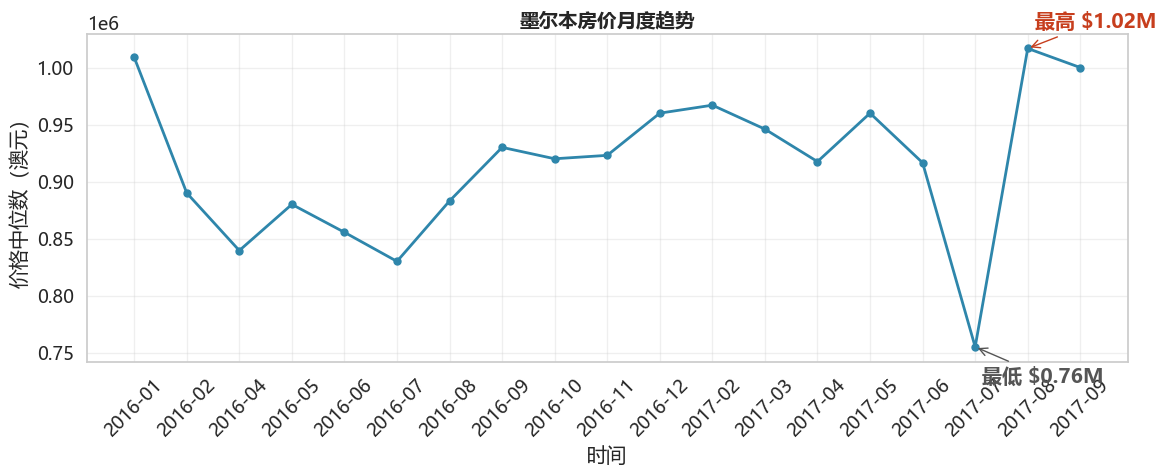

In [53]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_price = df.groupby('YearMonth')['Price'].median()

plt.figure(figsize=(12, 5))
plt.plot(monthly_price.index.astype(str), monthly_price.values,
         color='#2E86AB', linewidth=2, marker='o', markersize=5)

# 标注最高点
max_idx = monthly_price.idxmax()
max_val = monthly_price.max()
plt.annotate(f'最高 ${max_val/1e6:.2f}M',
             xy=(str(max_idx), max_val),
             xytext=(5, 15), textcoords='offset points',
             color='#C73E1D', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#C73E1D'))

# 标注最低点
min_idx = monthly_price.idxmin()
min_val = monthly_price.min()
plt.annotate(f'最低 ${min_val/1e6:.2f}M',
             xy=(str(min_idx), min_val),
             xytext=(5, -25), textcoords='offset points',
             color='#555555', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#555555'))

plt.title('墨尔本房价月度趋势', fontsize=14, fontweight='bold')
plt.xlabel('时间')
plt.ylabel('价格中位数（澳元）')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**说明：**
- 对柱状图和折线图进行美化，添加数值标签和关键点标注
- 柱状图标注各区域具体价格，折线图标出最高点和最低点
- 提升图表可读性，便于快速获取关键信息

## 四、总结

### 核心发现
1. **房价分布**：整体呈右偏分布，中位数约100万澳元，
   少数豪宅拉高均值，分析时以中位数为准

2. **关键影响因素**：房间数（0.50）和卫浴数（0.47）
   与房价相关性最强，距离市中心越远房价越低（-0.16）

3. **区域差异**：Glen Iris 房价最高（165万），
   Reservoir 最低（70万），差距超过2倍

4. **时间趋势**：2016~2017年整体上涨，
   每年年中为季节性低谷

### 数据质量说明
- BuildingArea 异常值较多，与房价相关性低，建模时需单独处理
- 清洗后剩余少量空值（YearBuilt 6条，CouncilArea 3条），
  占比0.07%，不影响分析结论